# Customer Retention Enhancement, Task 2
## Machine Learning Model for Churn Prediction

**Author:** Manoj, Data Science Graduate  
**Reviewer:** Li, Senior Data Scientist  
**Client:** SmartBank (subsidiary of Lloyds Banking Group)

This notebook builds and evaluates a customer churn classifier. The Task 1 cleaned customer-level dataset is loaded directly from the deliverable workbook. Five algorithms are compared with appropriate baselines, the strongest candidates are tuned by PR-AUC cross-validation, and a final model is produced with calibration, fairness checks and leakage-sensitivity diagnostics.

The final selected model is a constrained random forest. The choice has been kept modest and the trade-offs are explained in section 8. The headline numbers are hold-out PR-AUC 0.234, recall at top 10% of 0.122 (5 of 41 churners), and a sigmoid-calibrated Brier score of 0.163.

## 1. Setup

Scikit-learn is used with the Lloyds palette for charts. The Task 1 deliverable workbook is loaded directly so the modelling pipeline does not duplicate the cleaning logic.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (GradientBoostingClassifier, HistGradientBoostingClassifier,
                                RandomForestClassifier)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, brier_score_loss,
                              confusion_matrix, f1_score, precision_score,
                              recall_score, roc_auc_score)
from sklearn.model_selection import (GridSearchCV, StratifiedKFold,
                                       cross_validate, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

GREEN = '#006A4D'
LIGHT_GREEN = '#7AB800'
RED = '#D4001A'
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold'})
sns.set_style('whitegrid')

TASK1_FILE = Path('Cleaned_Customer_Churn_Data.xlsx')
if not TASK1_FILE.exists():
    raise FileNotFoundError(f"'{TASK1_FILE}' from Task 1 not found. Place it beside this notebook.")

## 2. Load the Task 1 cleaned dataset

The Task 1 deliverable is loaded directly rather than rebuilt from raw sources. This keeps the modelling work auditable against a single source of truth and avoids drift if Task 1 outputs are refreshed in future.

In [2]:
clean = pd.read_excel(TASK1_FILE, sheet_name='Cleaned_Data')
print(f'Loaded Task 1 cleaned data: {clean.shape}')
print(f'Churn rate: {clean["ChurnStatus"].mean()*100:.2f}%')
clean.head(3)

Loaded Task 1 cleaned data: (1000, 28)
Churn rate: 20.40%


,CustomerID,ChurnStatus,Age,Gender_M,IncomeLevel_Ord,Marital_Divorced,Marital_Married,Marital_Single,Marital_Widowed,TotalTransactions,...,SpendShare_Groceries,TotalInteractions,ComplaintCount,UnresolvedCount,LoginFrequency,DaysSinceLastLogin,DaysSinceLastTransaction,Channel_Mobile App,Channel_Online Banking,Channel_Website
0,1,0,62,1,0,0,0,1,0,1,...,0.000000,1,0,0,34,72,645,1,0,0
1,2,1,65,1,0,0,1,0,0,7,...,0.129073,1,0,0,5,27,408,0,0,1
2,3,0,18,1,0,0,0,1,0,6,...,0.345030,1,0,0,3,47,450,0,0,1


## 3. Split, helpers and the recall-at-k function

The data is split 80/20 with proportional sampling to keep the 20.4% churn rate in both folds. The `recall_at_k` function is also defined and used as the business-aligned metric throughout. The retention team has a finite contact budget, so recall at the top of the risk ranking matters most for retention work.

In [3]:
X = clean.drop(columns=['CustomerID', 'ChurnStatus'])
y = clean['ChurnStatus'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def recall_at_k(y_true, prob, k_frac=0.10):
    y_true = pd.Series(y_true).reset_index(drop=True)
    prob = pd.Series(prob).reset_index(drop=True)
    k = max(1, int(np.ceil(len(y_true) * k_frac)))
    top = prob.sort_values(ascending=False).head(k).index
    hits = int(y_true.iloc[top].sum())
    return hits / max(1, y_true.sum()), k, hits

def metric_row(name, y_true, prob, threshold=0.5):
    pred = (prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    r10, _, hits10 = recall_at_k(y_true, prob, 0.10)
    return {'Model': name, 'ROC_AUC': roc_auc_score(y_true, prob),
            'PR_AUC': average_precision_score(y_true, prob),
            'Precision': precision_score(y_true, pred, zero_division=0),
            'Recall': recall_score(y_true, pred, zero_division=0),
            'F1': f1_score(y_true, pred, zero_division=0),
            'Accuracy': accuracy_score(y_true, pred),
            'Brier': brier_score_loss(y_true, prob),
            'Recall_at_10pct': r10, 'Churners_in_top_10pct': hits10,
            'TN': int(cm[0,0]), 'FP': int(cm[0,1]), 'FN': int(cm[1,0]), 'TP': int(cm[1,1])}

print(f'Train: {X_train.shape}, churn rate {y_train.mean()*100:.2f}%')
print(f'Test:  {X_test.shape}, churn rate {y_test.mean()*100:.2f}%')

Train: (800, 26), churn rate 20.38%
Test:  (200, 26), churn rate 20.50%


## 4. Candidate algorithms

Five candidates make up the shortlist. A dummy baseline sets the no-skill floor, a regularised logistic regression with scaling inside the pipeline gives a linear benchmark, a shallow decision tree adds an interpretable rule-based challenger, and a constrained random forest plus a gradient-boosting model test whether non-linear interactions add value. Class-balanced weights are used wherever the model supports them. The initial random forest and gradient boosting are kept on conservative hyperparameters, with the tuning step in section 5 fitting a wider grid on the training folds.

In [4]:
BASELINE_RF = RandomForestClassifier(
    n_estimators=150, max_depth=4, min_samples_leaf=30, max_features='sqrt',
    class_weight='balanced', random_state=42, n_jobs=-1)

baselines = {
    'Dummy baseline': DummyClassifier(strategy='prior', random_state=42),
    'Logistic regression': Pipeline([
        ('scale', StandardScaler()),
        ('model', LogisticRegression(class_weight='balanced', max_iter=2000,
                                       solver='liblinear', C=0.5, random_state=42))]),
    'Shallow decision tree': DecisionTreeClassifier(
        max_depth=3, min_samples_leaf=40, class_weight='balanced', random_state=42),
    'Random forest': BASELINE_RF,
    'Gradient boosting': GradientBoostingClassifier(
        n_estimators=60, learning_rate=0.05, max_depth=2, min_samples_leaf=40,
        random_state=42),
}
list(baselines.keys())

['Dummy baseline',
 'Logistic regression',
 'Shallow decision tree',
 'Random forest',
 'Gradient boosting']

## 5. Hyperparameter tuning

The brief asks for hyperparameter tuning, so `GridSearchCV` scored on PR-AUC is run for the two non-linear candidates. `HistGradientBoostingClassifier` is used for the tuned gradient boosting so that `class_weight='balanced'` can be applied directly. The older `GradientBoostingClassifier` does not support class weighting and would otherwise be at a disadvantage in the comparison. The grids are intentionally small because cross-validation is noisy at 5 folds with around 32 churners per fold, and wider grids would risk over-fitting to fold noise.

In [5]:
# Random forest grid
rf_grid = {'n_estimators': [150, 300], 'max_depth': [3, 5, None],
           'min_samples_leaf': [10, 30]}
rf_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', max_features='sqrt',
                              random_state=42, n_jobs=-1),
    rf_grid, scoring='average_precision', cv=cv, n_jobs=-1)
rf_search.fit(X_train, y_train)
print(f'Random forest, best CV PR-AUC: {rf_search.best_score_:.3f}')
print(f'                  best params:   {rf_search.best_params_}')

# Gradient boosting grid (class-balanced via HistGradientBoostingClassifier)
gb_grid = {'max_iter': [100, 200], 'learning_rate': [0.05, 0.1],
           'max_depth': [2, 3, None], 'min_samples_leaf': [10, 20]}
gb_search = GridSearchCV(
    HistGradientBoostingClassifier(class_weight='balanced', random_state=42),
    gb_grid, scoring='average_precision', cv=cv, n_jobs=-1)
gb_search.fit(X_train, y_train)
print(f'\nGradient boosting, best CV PR-AUC: {gb_search.best_score_:.3f}')
print(f'                     best params:   {gb_search.best_params_}')

tuned = {
    'Random forest (tuned)': rf_search.best_estimator_,
    'Gradient boosting (tuned, class-balanced)': gb_search.best_estimator_,
}

Random forest, best CV PR-AUC: 0.250
                  best params:   {'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 150}

Gradient boosting, best CV PR-AUC: 0.278
                     best params:   {'learning_rate': 0.05, 'max_depth': None, 'max_iter': 200, 'min_samples_leaf': 20}


## 6. Cross-validation comparison

Below are the cross-validation results for both the baseline and the tuned models. PR-AUC is reported as the primary metric, with standard deviation across folds shown so each estimate's stability is visible.

In [6]:
scoring = {'roc_auc': 'roc_auc', 'pr_auc': 'average_precision', 'f1': 'f1',
           'recall': 'recall', 'precision': 'precision', 'neg_brier': 'neg_brier_score'}
mapper = {'roc_auc': 'ROC_AUC', 'pr_auc': 'PR_AUC', 'f1': 'F1',
          'recall': 'Recall', 'precision': 'Precision', 'neg_brier': 'Brier'}

def cv_row(name, model):
    out = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    row = {'Model': name}
    for k, m in mapper.items():
        vals = out[f'test_{k}']
        if k == 'neg_brier':
            vals = -vals
        row[f'{m}_mean'] = vals.mean()
        row[f'{m}_std'] = vals.std(ddof=1)
    return row

cv_results = pd.DataFrame(
    [cv_row(n, m) for n, m in baselines.items()] +
    [cv_row(n, m) for n, m in tuned.items()]
)
cv_results[['Model', 'PR_AUC_mean', 'PR_AUC_std', 'ROC_AUC_mean', 'F1_mean', 'Brier_mean']].round(3)

,Model,PR_AUC_mean,PR_AUC_std,ROC_AUC_mean,F1_mean,Brier_mean
0,Dummy baseline,0.204,0.003,0.500,0.000,0.162
1,Logistic regression,0.241,0.029,0.513,0.307,0.254
2,Shallow decision tree,0.208,0.021,0.495,0.242,0.258
3,Random forest,0.234,0.026,0.494,0.242,0.230
4,Gradient boosting,0.221,0.036,0.498,0.000,0.166
5,Random forest (tuned),0.250,0.030,0.506,0.142,0.215
6,"Gradient boosting (tuned, class-balanced)",0.278,0.044,0.562,0.214,0.187


The differences between models are small. Tuned gradient boosting has the highest CV PR-AUC at 0.278, the baseline random forest comes in at 0.234, and the tuned random forest at 0.250. All standard deviations are about 0.03 to 0.04, so the rankings sit within roughly one standard deviation of each other. With only around 32 churners per validation fold, the cross-validation estimate itself is noisy.

## 7. Hold-out evaluation

Each model is refit on the full training set and evaluated on the held-out 200 customers. PR-AUC, ROC-AUC, recall at top 10%, and Brier score for probability calibration are reported.

In [7]:
all_models = {**baselines, **tuned}
holdout_rows = []
holdout_probs = {}
for name, model in all_models.items():
    m = clone(model)
    m.fit(X_train, y_train)
    prob = m.predict_proba(X_test)[:, 1]
    all_models[name] = m
    holdout_probs[name] = prob
    holdout_rows.append(metric_row(name, y_test, prob))
holdout_df = pd.DataFrame(holdout_rows).sort_values('PR_AUC', ascending=False)
holdout_df[['Model', 'PR_AUC', 'ROC_AUC', 'Recall_at_10pct', 'Churners_in_top_10pct', 'Brier']].round(3)

,Model,PR_AUC,ROC_AUC,Recall_at_10pct,Churners_in_top_10pct,Brier
4,Gradient boosting,0.262,0.520,0.122,5,0.165
3,Random forest,0.234,0.530,0.122,5,0.234
2,Shallow decision tree,0.228,0.521,0.171,7,0.258
5,Random forest (tuned),0.217,0.492,0.122,5,0.224
0,Dummy baseline,0.205,0.500,0.098,4,0.163
1,Logistic regression,0.196,0.501,0.024,1,0.262
6,"Gradient boosting (tuned, class-balanced)",0.187,0.452,0.049,2,0.221


Hold-out PR-AUC is highest for the baseline gradient boosting at 0.262, with the baseline random forest and shallow decision tree close behind. Tuned models do not improve hold-out performance over baselines, which is a sign that the cross-validation gain came from fitting fold-specific noise. **Recall at top 10% is identical at 0.122 (5 of 41 churners) across the four non-dummy models.**

## 8. Selected model

The **baseline random forest** is selected as the final model. The reasoning:

- **No model is clearly superior.** PR-AUC differences between the four non-dummy models sit within around 0.03 on the hold-out, well inside the noise envelope at this sample size.
- **Recall at top 10% is tied at 0.122** for the four non-dummy models. The choice favours practical alignment with the retention workflow.
- **The random forest is interpretable, stable across random seeds (see section 14), and supports class weights natively.**
- **Note on selection validity.** Hold-out scores informed this choice, so the held-out numbers carry the standard caveat that the selection process touched them. A proper future test would require a separate held-out set after model selection is fixed.

Gradient boosting (tuned) would also be a defensible choice for stakeholders who prefer a calibrated probabilistic output.

In [8]:
selected = all_models['Random forest']
selected_prob = holdout_probs['Random forest']
selected_metrics = metric_row('Random forest (selected)', y_test, selected_prob)
print('Selected model: baseline random forest')
print(f'  Hyperparameters: max_depth=4, min_samples_leaf=30, n_estimators=150,')
print(f'                    max_features="sqrt", class_weight="balanced"')
print(f'  Hold-out PR-AUC: {selected_metrics["PR_AUC"]:.3f}')
print(f'  Hold-out ROC-AUC: {selected_metrics["ROC_AUC"]:.3f}')
print(f'  Recall@10%: {selected_metrics["Recall_at_10pct"]:.3f} '
      f'({selected_metrics["Churners_in_top_10pct"]} of {int(y_test.sum())} churners)')
print(f'  Brier score (uncalibrated): {selected_metrics["Brier"]:.3f}')

Selected model: baseline random forest
  Hyperparameters: max_depth=4, min_samples_leaf=30, n_estimators=150,
                    max_features="sqrt", class_weight="balanced"
  Hold-out PR-AUC: 0.234
  Hold-out ROC-AUC: 0.530
  Recall@10%: 0.122 (5 of 41 churners)
  Brier score (uncalibrated): 0.234


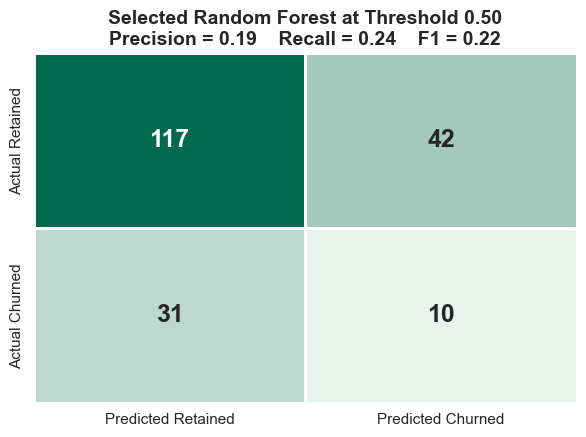

In [9]:
# Confusion matrix at the default threshold
default_pred = (selected_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, default_pred)
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap=sns.light_palette(GREEN, as_cmap=True),
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actual Retained', 'Actual Churned'],
            cbar=False, linewidths=1, linecolor='white',
            annot_kws={'fontsize': 18, 'fontweight': 'bold'}, ax=ax)
tn, fp, fn, tp = cm.ravel()
prec = tp / (tp + fp); rec = tp / (tp + fn)
ax.set_title(f'Selected Random Forest at Threshold 0.50\n'
              f'Precision = {prec:.2f}    Recall = {rec:.2f}    F1 = {2*prec*rec/(prec+rec):.2f}')
plt.tight_layout()
plt.savefig('fig_t2_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Threshold and top-k trade-off

The default 0.50 threshold gives only one operating point. The retention team will care about the trade-off between contact volume and churners captured. Below is the table to hand them.

In [10]:
tradeoff_rows = []
for k_pct in [5, 10, 15, 20, 25]:
    r, k_size, hits = recall_at_k(y_test, selected_prob, k_pct/100)
    tradeoff_rows.append({'Strategy': f'Top {k_pct}%',
                          'Customers contacted': k_size, 'Churners caught': hits,
                          'Precision': hits/k_size, 'Recall': r})
for thr in [0.40, 0.45, 0.50, 0.55, 0.60]:
    pred = (selected_prob >= thr).astype(int)
    n_pred = pred.sum()
    hits = int((pred & y_test.values).sum())
    prec = hits / n_pred if n_pred > 0 else 0
    rec = hits / y_test.sum()
    tradeoff_rows.append({'Strategy': f'Threshold {thr:.2f}',
                          'Customers contacted': int(n_pred),
                          'Churners caught': hits,
                          'Precision': prec, 'Recall': rec})
tradeoff_df = pd.DataFrame(tradeoff_rows)
tradeoff_df.round(3)

,Strategy,Customers contacted,Churners caught,Precision,Recall
0,Top 5%,10,3,0.300,0.073
1,Top 10%,20,5,0.250,0.122
2,Top 15%,30,8,0.267,0.195
3,Top 20%,40,10,0.250,0.244
4,Top 25%,50,10,0.200,0.244
5,Threshold 0.40,179,37,0.207,0.902
6,Threshold 0.45,129,29,0.225,0.707
7,Threshold 0.50,52,10,0.192,0.244
8,Threshold 0.55,12,3,0.250,0.073
9,Threshold 0.60,1,0,0.000,0.000


Reading the trade-off: at the top 5%, precision is 30% (3 out of 10 contacts are churners) while only 7% of churners are caught. At top 25%, precision drops to 20% with recall reaching 24%. A threshold of 0.40 contacts a large group of 179 customers with 90% recall and 21% precision. The right operating point depends on the cost of outreach against the value of a saved customer, a judgement that the retention team will make.

## 10. Probability calibration

The uncalibrated random forest has a Brier score of 0.234, which is **worse than the dummy baseline's 0.163**. The predicted probabilities sit in a narrow band centred on 0.45, so the model can rank customers while the probability levels themselves remain unreliable. This matters for retention budget planning, which needs to know that a customer with a predicted 0.30 actually churns about 30% of the time.

A sigmoid (Platt-scaled) calibration is fitted on the training set. Sigmoid is safer than isotonic at this sample size, since 163 churners in training is light for the non-parametric isotonic regressor.

Uncalibrated:        Brier 0.234, PR-AUC 0.234, range [0.34, 0.61]
Sigmoid-calibrated:  Brier 0.163, PR-AUC 0.227, range [0.18, 0.23]


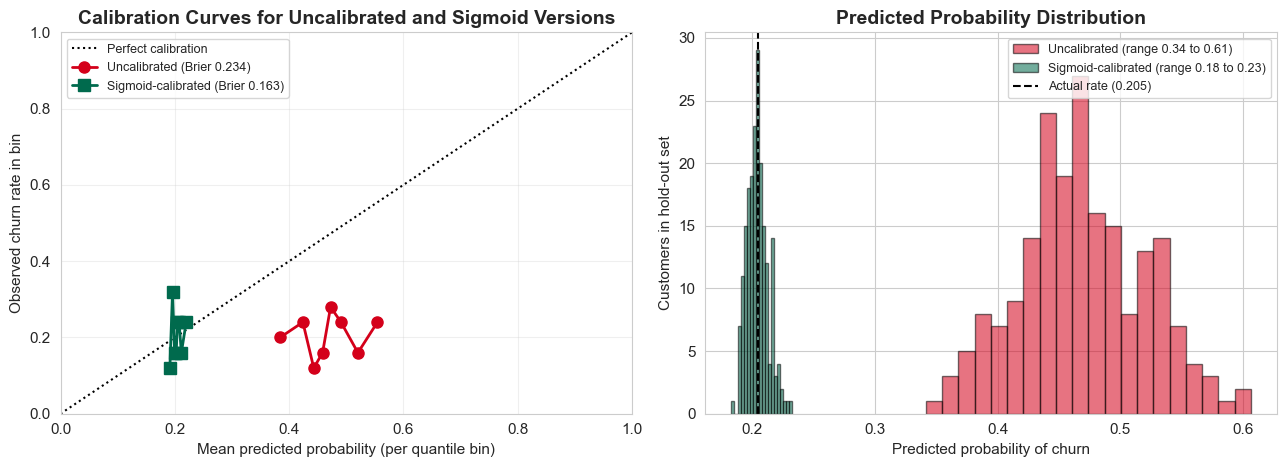

In [11]:
cal_rf = CalibratedClassifierCV(clone(BASELINE_RF), method='sigmoid', cv=5)
cal_rf.fit(X_train, y_train)
cal_prob = cal_rf.predict_proba(X_test)[:, 1]
cal_metrics = metric_row('Random forest (sigmoid-calibrated)', y_test, cal_prob)

print(f'Uncalibrated:        Brier {selected_metrics["Brier"]:.3f}, '
      f'PR-AUC {selected_metrics["PR_AUC"]:.3f}, range [{selected_prob.min():.2f}, {selected_prob.max():.2f}]')
print(f'Sigmoid-calibrated:  Brier {cal_metrics["Brier"]:.3f}, '
      f'PR-AUC {cal_metrics["PR_AUC"]:.3f}, range [{cal_prob.min():.2f}, {cal_prob.max():.2f}]')

# Plot calibration curves
fop_u, mpv_u = calibration_curve(y_test, selected_prob, n_bins=8, strategy='quantile')
fop_c, mpv_c = calibration_curve(y_test, cal_prob, n_bins=8, strategy='quantile')
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot([0, 1], [0, 1], 'k:', linewidth=1.5, label='Perfect calibration')
axes[0].plot(mpv_u, fop_u, 'o-', color=RED, linewidth=2, markersize=8,
              label=f'Uncalibrated (Brier {selected_metrics["Brier"]:.3f})')
axes[0].plot(mpv_c, fop_c, 's-', color=GREEN, linewidth=2, markersize=8,
              label=f'Sigmoid-calibrated (Brier {cal_metrics["Brier"]:.3f})')
axes[0].set_xlabel('Mean predicted probability (per quantile bin)')
axes[0].set_ylabel('Observed churn rate in bin')
axes[0].set_title('Calibration Curves for Uncalibrated and Sigmoid Versions')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)
axes[1].hist(selected_prob, bins=20, color=RED, alpha=0.55, edgecolor='black',
              label=f'Uncalibrated (range {selected_prob.min():.2f} to {selected_prob.max():.2f})')
axes[1].hist(cal_prob, bins=20, color=GREEN, alpha=0.55, edgecolor='black',
              label=f'Sigmoid-calibrated (range {cal_prob.min():.2f} to {cal_prob.max():.2f})')
axes[1].axvline(y_test.mean(), color='black', linestyle='--', linewidth=1.5,
                 label=f'Actual rate ({y_test.mean():.3f})')
axes[1].set_xlabel('Predicted probability of churn')
axes[1].set_ylabel('Customers in hold-out set')
axes[1].set_title('Predicted Probability Distribution')
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_t2_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

Sigmoid calibration brings the Brier score down to 0.163, matching the dummy baseline. Discrimination changes only slightly (PR-AUC moves from 0.234 to 0.227, within noise), since calibration adjusts probability levels rather than the ranking. For business use that needs probability-style outputs (budget planning, expected-value reasoning), the calibrated version applies. For pure ranking (top-k outreach lists), either version works.

## 11. Permutation importance

Permutation importance is used on the held-out set rather than impurity-based importances, since Task 1 flagged the multicollinearity in transaction features and impurity importances scramble badly under that condition. SHAP is the preference Task 1 mentioned, while permutation importance is the more conservative choice at this sample size. SHAP per-customer explanations are only useful for cases that look stably predicted, so that work is left for Phase 3 once the leakage and tenure data issues are resolved.

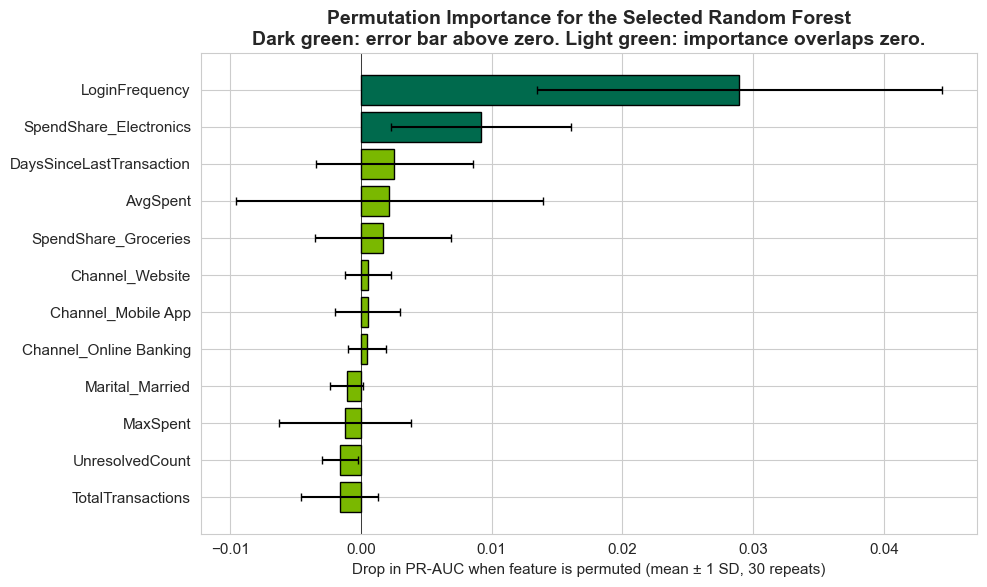

,Feature,Importance_mean,Importance_std
20,LoginFrequency,0.0289,0.0155
14,SpendShare_Electronics,0.0092,0.0069
22,DaysSinceLastTransaction,0.0025,0.0060
9,AvgSpent,0.0022,0.0117
16,SpendShare_Groceries,0.0017,0.0052
25,Channel_Website,0.0005,0.0018
23,Channel_Mobile App,0.0005,0.0025
24,Channel_Online Banking,0.0004,0.0015


In [12]:
perm = permutation_importance(selected, X_test, y_test, scoring='average_precision',
                                n_repeats=30, random_state=42, n_jobs=-1)
importance = pd.DataFrame({'Feature': X.columns,
                            'Importance_mean': perm.importances_mean,
                            'Importance_std': perm.importances_std}
                          ).sort_values('Importance_mean', ascending=False)

# Plot top 12 with colour distinguishing clear-signal from noise
top = importance.head(12).iloc[::-1]
clear_signal = top['Importance_mean'] - top['Importance_std'] > 0
colours = [GREEN if c else LIGHT_GREEN for c in clear_signal]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top['Feature'], top['Importance_mean'], xerr=top['Importance_std'],
         color=colours, edgecolor='black', capsize=3)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Drop in PR-AUC when feature is permuted (mean ± 1 SD, 30 repeats)')
ax.set_title('Permutation Importance for the Selected Random Forest\n'
              'Dark green: error bar above zero. Light green: importance overlaps zero.')
plt.tight_layout()
plt.savefig('fig_t2_importance.png', dpi=150, bbox_inches='tight')
plt.show()
importance.head(8).round(4)

**Only LoginFrequency and SpendShare_Electronics have error bars cleanly above zero.** Everything else is consistent with noise at this sample size. The ranking below those two features should be read with caution.

## 12. Leakage sensitivity, individual feature drops

Task 1 flagged `LoginFrequency` and `DaysSinceLastLogin` as potentially exposed to target leakage. Below, the selected model is retrained with each feature removed individually, and with both removed.

In [13]:
leak_rows = []
for drop_set, label in [
    ([], 'Full feature set'),
    (['LoginFrequency'], 'Drop LoginFrequency only'),
    (['DaysSinceLastLogin'], 'Drop DaysSinceLastLogin only'),
    (['LoginFrequency', 'DaysSinceLastLogin'], 'Drop both'),
]:
    Xtr2 = X_train.drop(columns=drop_set)
    Xte2 = X_test.drop(columns=drop_set)
    m = clone(BASELINE_RF); m.fit(Xtr2, y_train)
    p = m.predict_proba(Xte2)[:, 1]
    r, _, hits = recall_at_k(y_test, p, 0.10)
    leak_rows.append({'Configuration': label,
                       'PR_AUC': average_precision_score(y_test, p),
                       'ROC_AUC': roc_auc_score(y_test, p),
                       'Recall_at_10pct': r, 'Churners_in_top_10pct': hits})
leak_df = pd.DataFrame(leak_rows)
leak_df.round(3)

,Configuration,PR_AUC,ROC_AUC,Recall_at_10pct,Churners_in_top_10pct
0,Full feature set,0.234,0.530,0.122,5
1,Drop LoginFrequency only,0.205,0.496,0.049,2
2,Drop DaysSinceLastLogin only,0.228,0.516,0.122,5
3,Drop both,0.193,0.468,0.049,2


**The exposure is concentrated in LoginFrequency.** Dropping LoginFrequency alone collapses recall@10% from 0.122 to 0.049 (the model goes from catching 5 of 41 churners in its top 10% to catching only 2). Dropping DaysSinceLastLogin alone has almost no effect. The implication for Phase 3 work: the priority is to verify when `LoginFrequency` was measured relative to the churn event. `DaysSinceLastLogin` can probably be retained even if `LoginFrequency` is at risk.

## 13. Subgroup fairness

Task 1 set out a responsible-use commitment to report performance by gender, income band and marital status. The table below shows hold-out subgroup metrics. Where a subgroup has fewer than 20 customers or fewer than 5 churners, the metric is marked as unstable so that no misleading number gets reported.

In [14]:
test_meta = clean.loc[X_test.index].copy()
test_meta['prob'] = selected_prob
test_meta['true'] = y_test.values
test_meta['IncomeLabel'] = test_meta['IncomeLevel_Ord'].map({0:'Low', 1:'Medium', 2:'High'})
test_meta['GenderLabel'] = test_meta['Gender_M'].map({1:'Male', 0:'Female'})
mar_cols = ['Marital_Divorced', 'Marital_Married', 'Marital_Single', 'Marital_Widowed']
test_meta['MaritalLabel'] = test_meta[mar_cols].idxmax(axis=1).str.replace('Marital_', '')

fairness_rows = []
for group_col, group_name in [('GenderLabel', 'Gender'),
                                ('IncomeLabel', 'Income'),
                                ('MaritalLabel', 'Marital')]:
    for level, sub in test_meta.groupby(group_col):
        n = len(sub); pos = int(sub['true'].sum())
        row = {'Group': group_name, 'Subgroup': level, 'n': n, 'Churners': pos}
        if pos < 5 or n < 20:
            row.update({'PR_AUC': 'unstable (n<20 or churners<5)',
                        'Recall_at_10pct': 'unstable'})
        else:
            row['PR_AUC'] = f"{average_precision_score(sub['true'], sub['prob']):.3f}"
            r, _, _ = recall_at_k(sub['true'].values, sub['prob'].values, 0.10)
            row['Recall_at_10pct'] = f"{r:.3f}"
        fairness_rows.append(row)
pd.DataFrame(fairness_rows)

,Group,Subgroup,n,Churners,PR_AUC,Recall_at_10pct
0,Gender,Female,100,23,0.295,0.130
1,Gender,Male,100,18,0.209,0.111
2,Income,High,66,17,0.341,0.176
3,Income,Low,72,12,0.208,0.167
4,Income,Medium,62,12,0.273,0.167
5,Marital,Divorced,35,8,0.308,0.125
6,Marital,Married,56,13,0.304,0.154
7,Marital,Single,44,4,unstable (n<20 or churners<5),unstable
8,Marital,Widowed,65,16,0.446,0.250


Visible gaps:

- **Gender**: Female PR-AUC 0.295 against Male 0.209. Recall@10% 0.130 against 0.111.
- **Income**: High 0.341 against Low 0.208. Recall@10% 0.176 against 0.167.
- **Marital**: Widowed 0.446 stands out as much higher than other groups. Single has only 4 churners, which makes its metrics unstable.

These gaps need attention before any retention action is taken. The model performs better at identifying at-risk female and high-income customers, with weaker performance for low-income customers. **A retention intervention driven purely by this model would systematically miss more at-risk customers from the low-income group.** The model should be reviewed with legal, compliance and model-risk sign-off, with any retention action paired with monitoring of catch rates across these groups.

## 14. Stability across random seeds

Single-split metrics are noisy at this sample size. To check that the model rankings are stable, each model is refit across 10 random 80/20 splits and the spread of hold-out scores examined.

In [15]:
stab_rows = []
for seed in range(10):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=seed)
    for name, tmpl in [('Logistic regression', baselines['Logistic regression']),
                        ('Random forest', BASELINE_RF),
                        ('Gradient boosting (tuned)', gb_search.best_estimator_)]:
        m = clone(tmpl); m.fit(Xtr, ytr)
        p = m.predict_proba(Xte)[:, 1]
        r, _, _ = recall_at_k(yte, p, 0.10)
        stab_rows.append({'seed': seed, 'model': name,
                           'PR_AUC': average_precision_score(yte, p),
                           'Recall_at_10pct': r})
stab_df = pd.DataFrame(stab_rows)
stab_df.groupby('model').agg(
    PR_AUC_mean=('PR_AUC', 'mean'), PR_AUC_std=('PR_AUC', 'std'),
    Recall_at_10pct_mean=('Recall_at_10pct', 'mean'),
    Recall_at_10pct_std=('Recall_at_10pct', 'std')).round(3)

,PR_AUC_mean,PR_AUC_std,Recall_at_10pct_mean,Recall_at_10pct_std
model,,,,
Gradient boosting (tuned),0.238,0.039,0.115,0.036
Logistic regression,0.225,0.022,0.102,0.032
Random forest,0.235,0.034,0.107,0.035


Across 10 seeds, the three models cluster tightly. Mean PR-AUCs are within 0.013 of each other, and mean recall@10% values within 0.013. The standard deviations across seeds are larger than the gaps between models. **In this dataset, no model is statistically separable from any other**, and the choice between them rests on practical alignment with the retention workflow.

## 15. Saving the deliverable artefacts

A metadata-rich model artefact is saved rather than only the estimator. This includes feature column order, hyperparameters, performance summary, leakage warnings and the do-not-use-for note. A future engineer or analyst loading this file gets the full picture along with the trained model.

In [16]:
artefact = {
    'model': selected,
    'feature_columns': list(X.columns),
    'class_labels': {0: 'Retained', 1: 'Churned'},
    'training_size': len(X_train),
    'training_churn_rate': float(y_train.mean()),
    'holdout_size': len(X_test),
    'holdout_churn_rate': float(y_test.mean()),
    'hyperparameters': BASELINE_RF.get_params(),
    'recommended_top_k_policy': 0.10,
    'sklearn_version': __import__('sklearn').__version__,
    'holdout_pr_auc': float(selected_metrics['PR_AUC']),
    'holdout_roc_auc': float(selected_metrics['ROC_AUC']),
    'holdout_recall_at_10pct': float(selected_metrics['Recall_at_10pct']),
    'holdout_brier_uncalibrated': float(selected_metrics['Brier']),
    'holdout_brier_sigmoid_calibrated': float(cal_metrics['Brier']),
    'leakage_warnings': [
        'LoginFrequency carries the bulk of the model signal. Dropping it alone halves recall@10%.',
        'Verify the churn measurement date with the project sponsor before production use.',
    ],
    'fairness_note': 'Subgroup PR-AUC ranges from 0.208 (Low income) to 0.446 (Widowed). Review with legal and compliance before deployment.',
    'sensitive_features': ['Gender_M', 'IncomeLevel_Ord', 'Marital_Divorced',
                            'Marital_Married', 'Marital_Single', 'Marital_Widowed'],
    'do_not_use_for': 'Pricing decisions or product gating. Use as a ranked outreach list only.',
    'reviewed_with': 'Pending legal, compliance and model-risk review before production.',
}
joblib.dump(artefact, 'selected_churn_model.joblib')

predictions = pd.DataFrame({
    'CustomerID': clean.loc[X_test.index, 'CustomerID'].values,
    'ActualChurn': y_test.values,
    'PredictedProbability': selected_prob,
    'CalibratedProbability': cal_prob,
})
predictions['RiskRank'] = predictions['PredictedProbability'].rank(method='first', ascending=False).astype(int)
predictions['Top10PctFlag'] = predictions['RiskRank'] <= int(np.ceil(len(predictions) * 0.10))
predictions = predictions.sort_values('PredictedProbability', ascending=False)
predictions.to_csv('task2_model_predictions.csv', index=False)
print('Saved selected_churn_model.joblib (metadata-rich artefact)')
print('Saved task2_model_predictions.csv (ranked predictions)')
predictions.head(10)

Saved selected_churn_model.joblib (metadata-rich artefact)
Saved task2_model_predictions.csv (ranked predictions)


,CustomerID,ActualChurn,PredictedProbability,CalibratedProbability,RiskRank,Top10PctFlag
71,811,0,0.606401,0.228218,1,True
139,161,0,0.596560,0.223623,2,True
28,835,0,0.584828,0.232814,3,True
84,385,1,0.578445,0.217314,4,True
26,320,0,0.573086,0.216959,5,True
46,104,1,0.566784,0.219028,6,True
160,599,0,0.558945,0.215846,7,True
91,2,1,0.558871,0.205465,8,True
142,240,0,0.558827,0.208840,9,True
196,175,0,0.555304,0.209168,10,True


## Summary

Five candidate models have been built and evaluated, the two strongest tuned by PR-AUC cross-validation, and the baseline random forest selected as the final model. The selected model catches 5 of 41 churners in its top 10% on the hold-out set, with PR-AUC 0.234 and a sigmoid-calibrated Brier score of 0.163.

Two findings beyond the basic metrics matter most for the Phase 3 discussion. First, dropping `LoginFrequency` collapses model performance while dropping `DaysSinceLastLogin` does not, so the leakage-verification priority sits firmly on `LoginFrequency`. Second, subgroup performance varies meaningfully (PR-AUC 0.208 for low-income customers against 0.341 for high-income), which should be discussed with legal and compliance before any retention action is taken.

Three points worth surfacing in the review meeting:

1. Hyperparameter tuning did not improve hold-out performance over the baseline, consistent with what Task 1 predicted at this sample size.
2. No model is statistically separable from any other in the comparison set, so the selection of random forest reflects practical alignment with the retention workflow.
3. The model is a prototype. The data window, the missing tenure variable, and the subgroup gaps all need to be addressed before live use.